#### CSC 296S Deep Learning (Spring 2026)

#### Dr. Haiquan Chen, Dept of Computer Scicence

#### California State University, Sacramento



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports & Functions

In [40]:
import os, csv, re
import librosa
import numpy as np
import soundfile as sf
import random
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import soundfile
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import matplotlib.pyplot as plt
import librosa.display
import time
import gc


%pip install --upgrade torch torchvision torchaudio

## Data Prep

In [41]:
#seed for data randomization, hard coded for reproducability
SEED = 534
torch.manual_seed(SEED)
torch.backends.mps.deterministic = True
torch.backends.mps.benchmark = False

SAMPLE_RATE = 16000 #AST was pretrained on 16000 sample rate, not 44100hz
BATCH_SIZE = 32

In [42]:
#filepaths
training_dataset_csv_path = "/content/local_data/data/Train_Dataset.csv"
testing_dataset_csv_path = "/content/local_data/data/Test_Dataset.csv"
#training datasets
train_sound_training_data_path = "/content/local_data/data/training/train_sounds"
urban_ambient_training_data_path = "/content/local_data/data/training/urban_ambient"
#testing datasets
train_sound_testing_data_path = "/content/local_data/data/testing/Train"
urban_ambient_testing_data_path = "/content/local_data/data/testing/Urban_Ambiente"



## Creating Randomized CSV File and Data Frames

In [43]:
#helper function, sorts audio files into a consistant order when building the csv
def extract_first_two_numbers(file_name):
    #check regex of file name
    match = re.match(r"(\d+)_(\d+)_", file_name)
    #return (38, 1)
    if match:
        first_num, second_num = int(match.group(1)), int(match.group(2))
        return first_num, second_num
    #if filename does not match pattern
    return float('inf'), float('inf')

In [44]:
#create the CSV files for file accessability

#for training dataset
with open(training_dataset_csv_path, 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter=',')
    writer.writerow(['audio_name', 'label', 'path'])

    for path, dirs, files in os.walk(train_sound_training_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)

        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'train_sound', full_path])

    for path, dirs, files in os.walk(urban_ambient_training_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)

        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'urban_ambient', full_path])

#for testing dataset
with open(testing_dataset_csv_path, 'w+', newline='') as csv_file:
    writer = csv.writer(csv_file, delimiter=',')
    writer.writerow(['audio_name', 'label', 'path'])

    for path, dirs, files in os.walk(train_sound_testing_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)

        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'train_sound', full_path])

    for path, dirs, files in os.walk(urban_ambient_testing_data_path):
        sorted_files = sorted(files, key=extract_first_two_numbers)

        for file_name in sorted_files:
            if file_name.endswith('.wav'):
                full_path = os.path.normpath(os.path.join(path, file_name))
                writer.writerow([file_name, 'urban_ambient', full_path])



In [45]:
#training dataset info
dataframe_training = pd.read_csv(training_dataset_csv_path)
dataframe_training.tail()

,audio_name,label,path
35852,505_0_Amb_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/training/urban_ambien...
35853,505_1_Amb_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/training/urban_ambien...
35854,505_2_Amb_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/training/urban_ambien...
35855,505_3_Amb_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/training/urban_ambien...
35856,505_4_Amb_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/training/urban_ambien...


In [46]:
#testing dataset info
dataframe_testing = pd.read_csv(testing_dataset_csv_path)
dataframe_testing.tail()

,audio_name,label,path
6239,454_0_Test_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/testing/Urban_Ambient...
6240,454_1_Test_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/testing/Urban_Ambient...
6241,454_2_Test_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/testing/Urban_Ambient...
6242,454_3_Test_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/testing/Urban_Ambient...
6243,454_4_Test_TUT_2018_street_pedestrian.wav,urban_ambient,/content/local_data/data/testing/Urban_Ambient...


## Shuffle the Datasets Based on Random State Seed

In [47]:
dataframe_training = dataframe_training.sample(frac=1, random_state=SEED).reset_index(drop=False)
dataframe_testing = dataframe_testing.sample(frac=1, random_state=SEED).reset_index(drop=False)

## Create Dataset with Mel Spectogram using AST Feature Extractor
AST Feature Extractor has its own specific Mel Spectrogram hyperparameters

In [48]:
import torch
import librosa
from torch.utils.data import Dataset

class ASTAudioDataset(Dataset):
    def __init__(self, dataframe, feature_extractor):
        self.dataframe = dataframe
        self.feature_extractor = feature_extractor
        self.cache = {}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        if idx in self.cache:
            return self.cache[idx]

        audio_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['label']

        raw_audio, _ = librosa.load(audio_path, sr=16000)

        # use max_length=512 for speed/memory efficiency since clips are only 2s long
        inputs = self.feature_extractor(
            raw_audio,
            sampling_rate=16000,
            padding="max_length",
            max_length=512,
            truncation=True,
            return_tensors="pt"
        )

        features = inputs['input_values'].squeeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)

        self.cache[idx] = (features, label_tensor)

        return features, label_tensor

In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataframe_training['label'] = le.fit_transform(dataframe_training['label'])

dataframe_testing['label'] = le.transform(dataframe_testing['label'])

print("Label mapping classes:", le.classes_)
print("0 = train, 1 = urban_ambient")

Label mapping classes: ['train_sound' 'urban_ambient']
0 = train, 1 = urban_ambient


In [50]:
from transformers import AutoFeatureExtractor

extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

training_dataset = ASTAudioDataset(dataframe_training, feature_extractor=extractor)
testing_dataset = ASTAudioDataset(dataframe_testing, feature_extractor=extractor)

training_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)
testing_loader  = DataLoader(testing_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)

for features, labels in training_loader:
    print(f"Feature batch shape (Batch, Time, Mel_Bins) : {features.shape}")
    print(f"Label batch shape   : {labels.shape}")
    break

Feature batch shape (Batch, Time, Mel_Bins) : torch.Size([32, 1024, 128])
Label batch shape   : torch.Size([32])


## Model
Pre-Trained Audio Spectrogram Transformer


In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import ASTForAudioClassification
from tqdm import tqdm

In [52]:
# setup device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Training on: {device}")

# load pretrained model
# use ignore_mismatched_sizes=True to swap the 527-class head for our 2-class head
model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=2,
    attn_implementation="sdpa",
    ignore_mismatched_sizes=True
)
model.to(device)

Training on: cuda


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([2, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=T

Architecture diagram saved to: /content/drive/MyDrive/Sac_State/Deep_Learning/ast_architecture.png


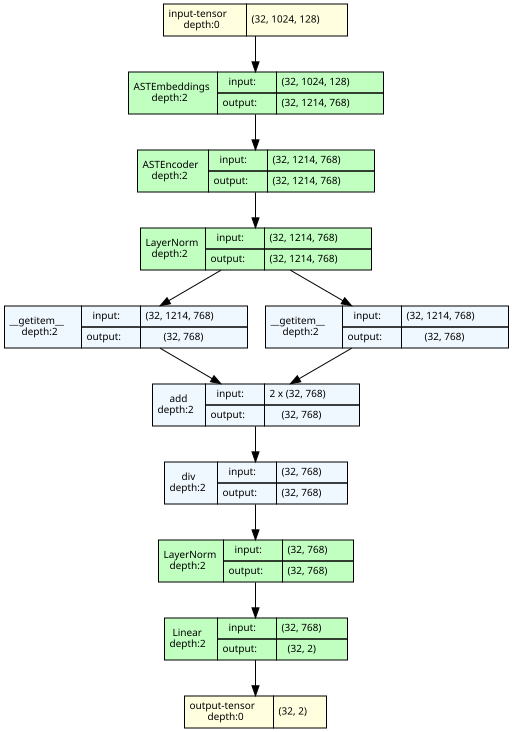

In [66]:
from torchview import draw_graph
import torch
import os

dummy_input = torch.randn(32, 1024, 128).to(device)

model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=False,
    depth=2,
    device=device,
    save_graph=False
)

save_path = '/content/drive/MyDrive/Sac_State/Deep_Learning/ast_architecture'

model_graph.visual_graph.render(save_path, format='png', cleanup=True)

print(f"Architecture diagram saved to: {save_path}.png")

model_graph.visual_graph

In [53]:
# AST requires a much lower learning rate than CNNs (5e-5 is a standard starting point)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [54]:
import torch
import torch.nn as nn
import gc
import pickle
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def plot_results(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Sac_State/Deep_Learning/final_training_plot_2.png', dpi=300)

    plt.show()

def evaluate_final(model, test_loader, le_classes):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            outputs = model(input_values=features).logits
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy()[:, 1])

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=le_classes))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_classes)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

    print("\n--- AU ROC Curve ---")
    auc_score = roc_auc_score(all_labels, all_probs)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AST Model (area = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()

In [55]:



def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs=10, patience=3):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_model_path = "/content/drive/MyDrive/Sac_State/Deep_Learning/ast_best_model_full_1024_ls_005.pt"

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for features, labels in loop:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(input_values=features).logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            loop.set_postfix(loss=loss.item(), acc=100.*correct_train/total_train)

        avg_train_loss = running_loss / len(train_loader.dataset)
        avg_train_acc = 100. * correct_train / total_train

        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for features, labels in test_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(input_values=features).logits
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * features.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(test_loader.dataset)
        avg_val_acc = 100. * correct_val / total_val
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        history['lr'].append(current_lr)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.2f}% | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
            torch.save({'model_state_dict': model.state_dict(), 'history': history}, best_model_path)
            print(f"--> New Best Model saved to Drive!")
        else:
            epochs_without_improvement += 1
            print(f"--> No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= patience:
            print(f"!!! Early Stopping triggered at Epoch {epoch+1}.")
            break

        scheduler.step()
    return history

In [116]:


# clear memory before starting
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): torch.mps.empty_cache()

# start training
history = train_model(model, training_loader, testing_loader, criterion, optimizer, scheduler, epochs=10, patience=3)

with open('/content/drive/MyDrive/Sac_State/Deep_Learning/training_history_1024_ls_005.pkl', 'wb') as f:
    pickle.dump(history, f)

# reload best weights for evaluation
checkpoint = torch.load("/content/drive/MyDrive/Sac_State/Deep_Learning/ast_best_model_1024_ls_005.pt")
model.load_state_dict(checkpoint['model_state_dict'])

plot_results(history)
evaluate_final(model, testing_loader, le.classes_)


Epoch 1/10 [Train]: 100%|██████████| 1120/1120 [26:54<00:00,  1.44s/it, acc=97.2, loss=0.122]


Epoch 1: Train Loss: 0.1761 | Acc: 97.18% | Val Loss: 0.3390 | Acc: 90.74% | LR: 0.000050
--> New Best Model saved to Drive!


Epoch 2/10 [Train]: 100%|██████████| 1120/1120 [26:55<00:00,  1.44s/it, acc=99, loss=0.12]


Epoch 2: Train Loss: 0.1394 | Acc: 98.98% | Val Loss: 0.4164 | Acc: 88.37% | LR: 0.000049
--> No improvement for 1 epoch(s).


Epoch 3/10 [Train]: 100%|██████████| 1120/1120 [26:55<00:00,  1.44s/it, acc=99.4, loss=0.119]


Epoch 3: Train Loss: 0.1320 | Acc: 99.35% | Val Loss: 0.5324 | Acc: 85.32% | LR: 0.000045
--> No improvement for 2 epoch(s).


Epoch 4/10 [Train]: 100%|██████████| 1120/1120 [26:55<00:00,  1.44s/it, acc=99.5, loss=0.118]


Epoch 4: Train Loss: 0.1287 | Acc: 99.46% | Val Loss: 0.5099 | Acc: 86.06% | LR: 0.000040
--> No improvement for 3 epoch(s).
!!! Early Stopping triggered at Epoch 4.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Sac_State/Deep_Learning/ast_best_model_1024_ls_005.pt'

Model differences: changed window to 1024 samples from 512 samples and reduced label_smoothing to 0.05 from 0.1

## Plots of best model

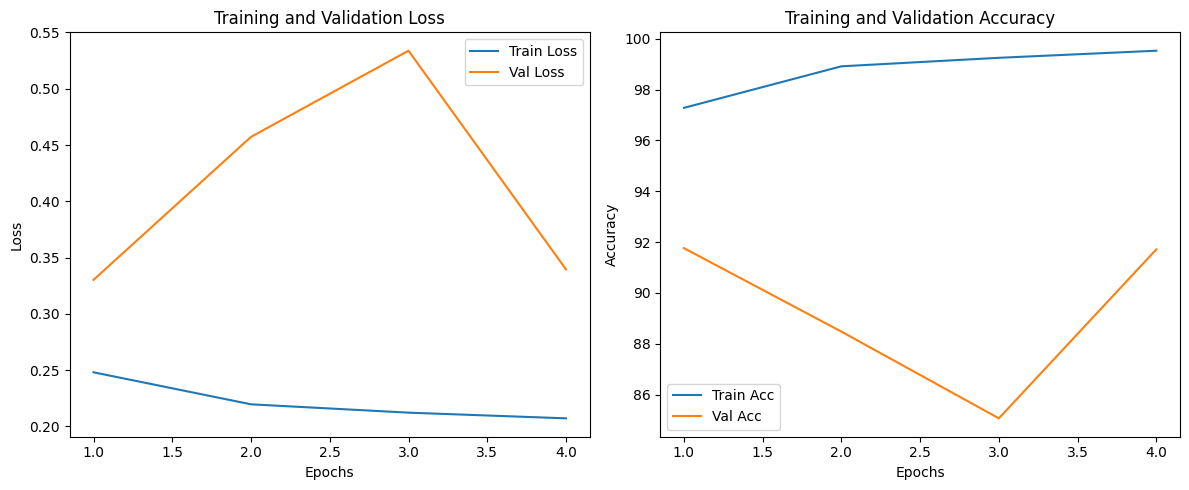


--- Classification Report ---
               precision    recall  f1-score   support

  train_sound       0.97      0.86      0.91      3116
urban_ambient       0.87      0.98      0.92      3124

     accuracy                           0.92      6240
    macro avg       0.92      0.92      0.92      6240
 weighted avg       0.92      0.92      0.92      6240


--- Confusion Matrix ---


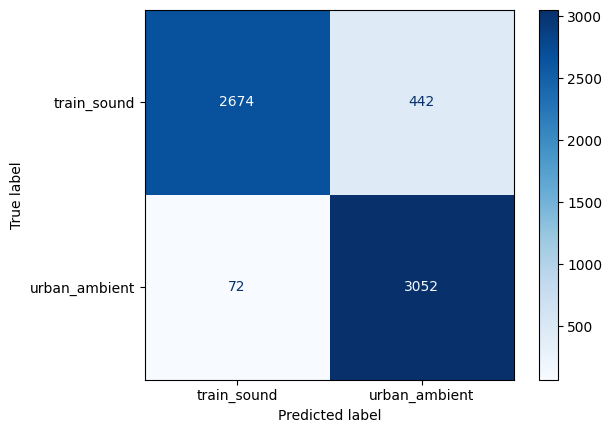


--- AU ROC Curve ---


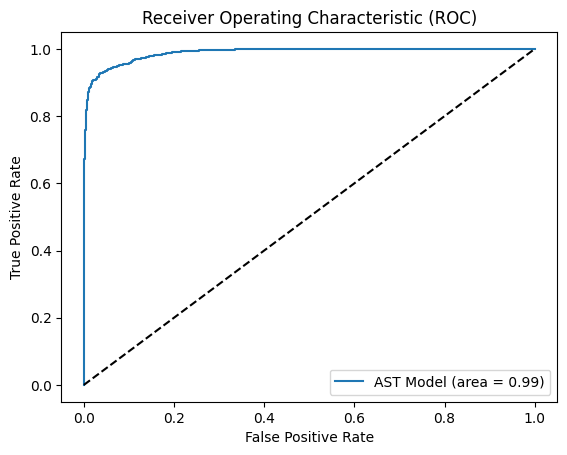

In [67]:

# reload best model weights
checkpoint = torch.load("/content/drive/MyDrive/Sac_State/Deep_Learning/evaluation_data/model 1/ast_best_model_full.pt")
model.load_state_dict(checkpoint['model_state_dict'])

with open('/content/drive/MyDrive/Sac_State/Deep_Learning/evaluation_data/model 1/training_history_full.pkl', 'rb') as f:
        history = pickle.load(f)

plot_results(history)
evaluate_final(model, testing_loader, le.classes_)

## Data transfer from drive to local machine

In [20]:
!mkdir -p /content/local_data

In [21]:
!rsync -ah --progress /content/drive/MyDrive/Sac_State/Deep_Learning/data.zip /content/

sending incremental file list
data.zip
          5.86G 100%   82.85MB/s    0:01:07 (xfr#1, to-chk=0/1)


In [22]:
!unzip -q /content/data.zip -d /content/local_data/